# Workshop 2 - Machine Learning (Unidad 2)
## Clasificación - Thyroid Disease Data

**Integrantes:**
- Juan José Escobar Saldarriaga
- Jeremías Figueroa García
- David Quintero Gallego

**Fecha:** 2026-09-01

---

Pipelines, entrenamiento, comparación de modelos y validación cruzada. Este notebook resuelve el problema de **clasificación** usando el dataset **Thyroid Disease Data**.

Dataset: https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data

**Nota:** el workshop completo consta de 2 notebooks - este (clasificación) y su contraparte de regresión. El punto 28 (conclusiones, Fase 8) pide comparar ambos problemas; esa comparación debe ser consistente entre los dos notebooks.

Cada punto requiere código **y** una celda de justificación en markdown explicando la decisión tomada - no basta con ejecutar el código.

---

# Fase 0 — Importación de librerías y datos

**En caso de trabajar con Google Colab, es necesario descargar el dataset en Drive y conectar el notebook con drive:**

In [1]:
# Celda omitida: solo aplica en Google Colab


## Librerías

Importa aquí todas las librerías que vas a necesitar. Como mínimo:
- `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- De `sklearn.model_selection`: `train_test_split`, `cross_val_score` o `cross_validate`
- De `sklearn.compose`: `ColumnTransformer`
- De `sklearn.pipeline`: `Pipeline`
- De `sklearn.preprocessing`: `StandardScaler`, `MinMaxScaler`, `RobustScaler`, `OneHotEncoder`, `OrdinalEncoder`
- De `sklearn.impute`: `SimpleImputer`
- Modelos: `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`
- Métricas: `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`

In [2]:
# Importa aquí todas las librerías necesarias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define random_state para reproducibilidad:
random_state = 42

---

# Fase 1 — EDA, limpieza y preprocesamiento

## 1. Descripción del problema y variable objetivo

Lea la documentación del dataset y describa el problema de salud que representa. Identifique cuál es la variable objetivo (target).

El dataset recopila 13 características clinicopatológicas de pacientes con cáncer de tiroides bien diferenciado, con el objetivo de predecir su recurrencia después del tratamiento inicial. Los datos se recolectaron durante un periodo de 15 años, y cada paciente fue objeto de seguimiento durante al menos 10 años, lo que da al problema una perspectiva longitudinal poco común en datasets tabulares típicos. Provienen originalmente del UCI Machine Learning Repository (Differentiated Thyroid Cancer Recurrence dataset) y llegan a Kaggle ya consolidados en un único archivo tabular.

Las 17 columnas del dataset son: Age (edad del paciente al momento del diagnóstico o tratamiento), Gender (género), Smoking (si el paciente fuma actualmente), Hx Smoking (historial de tabaquismo, es decir, si ha fumado alguna vez), Hx Radiothreapy (historial de radioterapia por cualquier condición previa), Thyroid Function (estado funcional de la tiroides), Physical Examination (hallazgos del examen físico, como palpación de la glándula), Adenopathy (presencia y localización de ganglios linfáticos agrandados en el cuello), Pathology (subtipo específico de cáncer determinado por biopsia), Focality (si el cáncer está localizado en un solo punto o es multifocal), Risk (categoría de riesgo según tamaño del tumor, extensión y tipo histológico), T (clasificación del tumor primario según tamaño e invasión), N (clasificación según compromiso de ganglios linfáticos), M (clasificación según presencia de metástasis a distancia), Stage (estadio general del cáncer, resultado de combinar T, N y M), Response (respuesta observada al tratamiento) y Recurred (si el cáncer reapareció después del tratamiento).

El problema de salud representado es, en esencia, de pronóstico oncológico: a partir de características demográficas, clínicas e histopatológicas disponibles después del tratamiento inicial, se busca anticipar qué pacientes tienen mayor probabilidad de que el cáncer reaparezca, información valiosa para decidir la intensidad del seguimiento posterior.

La **variable objetivo (target)** es **Recurred**, con dos valores posibles (Yes / No), por lo que se trata de un problema de **clasificación binaria**.

## 2. Carga del dataset y diccionario de datos

Cargue el dataset con pandas, muestre `head()`/`tail()`, `.shape` y `.info()`. Construya el diccionario de datos (columna, tipo esperado, significado).

In [3]:
# Carga del dataset:
df = pd.read_csv('data/Thyroid_Diff.csv')

In [4]:
# head() / tail():
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
df.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [6]:
# .shape y .info():
df.shape

(383, 17)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

**Filas:** `383`
**Columnas:** `17`

**Diccionario de datos:**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Age` | Numérico (entero) | Edad del paciente al momento del diagnóstico o tratamiento |
| `Gender` | Categórico binario | Género del paciente (F / M) |
| `Smoking` | Categórico binario | Si el paciente es fumador activo (Yes / No) |
| `Hx Smoking` | Categórico binario | Historial de tabaquismo, si ha fumado alguna vez (Yes / No) |
| `Hx Radiothreapy` | Categórico binario | Historial de radioterapia por cualquier condición previa (Yes / No) |
| `Thyroid Function` | Categórico (5 categorías) | Estado funcional de la tiroides (eutiroidea, hiper o hipotiroidismo clínico o subclínico) |
| `Physical Examination` | Categórico (5 categorías) | Hallazgos del examen físico de la glándula tiroides |
| `Adenopathy` | Categórico (6 categorías) | Presencia y localización de ganglios linfáticos agrandados en el cuello |
| `Pathology` | Categórico (4 categorías) | Subtipo histológico del cáncer determinado por biopsia |
| `Focality` | Categórico binario | Si el cáncer es unifocal o multifocal (Uni-Focal / Multi-Focal) |
| `Risk` | Categórico ordinal (3 categorías) | Categoría de riesgo de recurrencia (Low, Intermediate, High) |
| `T` | Categórico ordinal (7 categorías) | Clasificación del tumor primario según tamaño e invasión (T1a a T4b) |
| `N` | Categórico ordinal (3 categorías) | Clasificación según compromiso de ganglios linfáticos (N0, N1a, N1b) |
| `M` | Categórico binario | Presencia de metástasis a distancia (M0 / M1) |
| `Stage` | Categórico ordinal (5 categorías) | Estadio general del cáncer (I, II, III, IVA, IVB) |
| `Response` | Categórico (4 categorías) | Respuesta observada al tratamiento |
| `Recurred` | Categórico binario (target) | Si el cáncer reapareció después del tratamiento (Yes / No) |

Como se observa, **Age es la única columna numérica**; las 16 restantes son categóricas, varias de ellas binarias.

**Observaciones iniciales:**

* Según `.info()`, ninguna columna tiene valores nulos, lo que sugiere que el dataset ya cuenta con cierto nivel de limpieza previa, similar a lo que se observó en el dataset de vuelos.
* Varias columnas categóricas son en realidad binarias (Gender, Smoking, Hx Smoking, Hx Radiothreapy, Focality, M y el propio target Recurred), lo que facilita su codificación más adelante: para las que tienen un orden interpretable hacia el resultado (por ejemplo, Smoking: fumar sí puede asociarse a peor pronóstico) se puede usar una codificación 0/1 tipo Ordinal, y para las que no tienen esa interpretación direccional (como Gender) alcanza con un One-Hot equivalente. El propio target también puede pensarse ya como 0 (No recurrencia) y 1 (Sí recurrencia).
* Al revisar `head()`/`tail()` se ven columnas con valores de texto más complejos (por ejemplo, en Physical Examination o Thyroid Function), por lo que será importante revisar en el punto 6 que no existan inconsistencias de formato como mayúsculas, espacios o guiones mal puestos entre categorías que deberían ser la misma.
* El dataset es relativamente pequeño (383 registros), lo cual habrá que tener en cuenta al dividir entre train, validation y test más adelante; si los modelos no logran entrenar bien por esta limitación, se podría considerar más adelante alguna técnica de oversampling (como SMOTE) para la clase minoritaria del target.

## 3. Estadísticos descriptivos

Use `.describe()` para las columnas numéricas. Interprete al menos 3 estadísticos en términos del problema.

In [8]:
# .describe():
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [9]:
# Verificacion del balance de Gender citado en la interpretacion del punto 3
df['Gender'].value_counts(normalize=True).mul(100).round(1)

Gender
F    81.5
M    18.5
Name: proportion, dtype: float64

**Interpretación:**

* La media de edad es de 40.9 años y la mediana de 37 años, cifras que tienen sentido clínico: según la American Cancer Society, el cáncer de tiroides suele diagnosticarse con mayor frecuencia entre los 30 y 50 años en mujeres, y entre los 60 y 70 en hombres, y las mujeres son cerca de 3 veces más propensas a desarrollarlo. Esto es consistente con lo que se observa más adelante en el dataset: 81.5% de los registros son mujeres frente a 18.5% de hombres, una proporción incluso más marcada que ese 3 a 1 de referencia (Ref: American Cancer Society, factores de riesgo del cáncer de tiroides).
* La desviación estándar es de 15.1 años, un valor considerable que indica bastante variabilidad en las edades registradas, coherente con que el diagnóstico puede darse en un rango amplio (15 a 82 años en este dataset) y no concentrarse en una única década de vida.
* El mínimo es 15 años y el máximo 82 años. Ambos están apenas por fuera de los rangos típicos mencionados arriba, pero no son valores extremos o inverosímiles para un diagnóstico de cáncer de tiroides. Entre el mínimo y el percentil 25 (29 años) hay aproximadamente una desviación estándar de diferencia, mientras que entre el percentil 75 (51 años) y el máximo hay cerca de dos desviaciones estándar, lo que sugiere que la cola derecha de la distribución (pacientes de mayor edad) está algo más dispersa que la izquierda.
* La media (40.9) es unos 3 años mayor que la mediana (37), lo que indica un sesgo leve hacia la derecha: hay un grupo de pacientes de edad más avanzada que empuja la media hacia arriba, algo esperable dado que el riesgo de este tipo de cáncer aumenta con la edad. Al ser una diferencia de solo 3 años, el sesgo es moderado y no distorsiona demasiado la interpretación de la media.

## 4. Valores nulos: identificación y estrategia

Identifique valores nulos por columna, calcule su porcentaje, y proponga una estrategia de imputación o eliminación. Justifique según el porcentaje de nulos y el tipo de variable.

In [10]:
# Nulos por columna y porcentaje:
df.isnull().sum()

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

In [11]:
df.isnull().sum() / len(df) * 100

Age                     0.0
Gender                  0.0
Smoking                 0.0
Hx Smoking              0.0
Hx Radiothreapy         0.0
Thyroid Function        0.0
Physical Examination    0.0
Adenopathy              0.0
Pathology               0.0
Focality                0.0
Risk                    0.0
T                       0.0
N                       0.0
M                       0.0
Stage                   0.0
Response                0.0
Recurred                0.0
dtype: float64

**Estrategia de tratamiento de nulos y justificación:**

`.isnull().sum()` confirma que ninguna de las 17 columnas tiene valores nulos (0% en todas). Por lo tanto, no se requiere ninguna estrategia de imputación ni eliminación de filas o columnas por este motivo; el dataset ya llega completo en este aspecto.

## 5. Duplicados

Identifique y elimine duplicados si existen. Reporte cuántos se eliminaron.

In [12]:
# Identificación y eliminación de duplicados:
df.duplicated().sum()

np.int64(19)

In [13]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
119,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
123,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No


In [14]:
# Eliminacion de duplicados:
filas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
filas_despues = df.shape[0]

print(f'Filas antes: {filas_antes}')
print(f'Filas despues: {filas_despues}')
print(f'Duplicados eliminados: {filas_antes - filas_despues}')

Filas antes: 383
Filas despues: 364
Duplicados eliminados: 19


In [15]:
df.describe()

,Age
count,364.00000
mean,41.25000
std,15.31436
min,15.00000
25%,30.00000
50%,38.00000
75%,52.00000
max,82.00000


**Observación:** se identificaron 19 filas completamente duplicadas (4.96% del dataset) y se eliminaron, quedando 364 registros.

No existe una columna identificadora de paciente en el dataset, así que no hay forma de confirmar con certeza si estas filas corresponden a la misma persona registrada más de una vez o a pacientes distintos que, por coincidencia, comparten exactamente el mismo perfil clínico. Sin embargo, revisando el contenido de los duplicados, no parecen errores de captura: los 19 registros corresponden todos a pacientes mujeres, sin hábito de fumar, con función tiroidea normal (Euthyroid), sin adenopatía, con subtipos de cáncer poco agresivos (Papillary o Micropapillary), enfermedad unifocal, Estadio I, respuesta excelente al tratamiento y sin recurrencia. Es decir, todos comparten el perfil clínico más favorable posible dentro del dataset, uno que es clínicamente común (mujeres relativamente jóvenes con papilar de bajo riesgo son, de hecho, el perfil más frecuente de cáncer de tiroides), por lo que es razonable que varias pacientes distintas coincidan exactamente en esa combinación de características, la mayoría categóricas y de pocos valores posibles.

Aun así, se optó por eliminarlos en lugar de solo reportarlos, principalmente para evitar fuga de datos entre los conjuntos de train, validation y test: si estas filas duplicadas quedaran repartidas entre distintos conjuntos, el modelo podría "ver" en test un registro idéntico a uno usado en entrenamiento, inflando artificialmente las métricas de evaluación. Aunque eliminar el 4.96% de un dataset ya pequeño (383 registros) no es ideal, el riesgo de fuga de datos pesa más que la pérdida de esas 19 filas, sobre todo porque no reducen la diversidad de perfiles clínicos representados (el perfil favorable sigue estando presente en el dataset, solo que sin repetirse).

## 6. Inconsistencias de formato

Revise inconsistencias de formato en columnas categóricas o de texto (mayúsculas/minúsculas, espacios, etiquetas equivalentes) y corríjalas.

In [16]:
# Revisión con .unique() de columnas categóricas/texto:
df['Gender'].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [17]:
df['Smoking'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [18]:
df['Hx Smoking'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [19]:
df['Hx Radiothreapy'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [20]:
df['Physical Examination'].unique()

<StringArray>
[ 'Single nodular goiter-left',         'Multinodular goiter',
 'Single nodular goiter-right',                      'Normal',
              'Diffuse goiter']
Length: 5, dtype: str

In [21]:
df['Adenopathy'].unique()

<StringArray>
['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior']
Length: 6, dtype: str

In [22]:
df['Pathology'].unique()

<StringArray>
['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell']
Length: 4, dtype: str

In [23]:
df['Focality'].unique()

<StringArray>
['Uni-Focal', 'Multi-Focal']
Length: 2, dtype: str

In [24]:
df['Risk'].unique()

<StringArray>
['Low', 'Intermediate', 'High']
Length: 3, dtype: str

In [25]:
df['T'].unique()

<StringArray>
['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
Length: 7, dtype: str

In [26]:
df['N'].unique()

<StringArray>
['N0', 'N1b', 'N1a']
Length: 3, dtype: str

In [27]:
df['M'].unique()

<StringArray>
['M0', 'M1']
Length: 2, dtype: str

In [28]:
df['Stage'].unique()

<StringArray>
['I', 'II', 'IVB', 'III', 'IVA']
Length: 5, dtype: str

In [29]:
df['Response'].unique()

<StringArray>
['Indeterminate', 'Excellent', 'Structural Incomplete',
 'Biochemical Incomplete']
Length: 4, dtype: str

In [30]:
df['Recurred'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

**Justificación de las correcciones:**

Se revisaron con `.unique()` las 16 columnas categóricas del dataset y no se encontró ninguna inconsistencia de formato: no hay diferencias de mayúsculas/minúsculas para una misma categoría, ni espacios sobrantes, ni etiquetas equivalentes escritas de forma distinta (por ejemplo, "Yes"/"yes" o "Low"/"low"). Todas las categorías están escritas de forma consistente, así que no fue necesaria ninguna corrección.

Esto refuerza la idea de que el dataset ya cuenta con cierto nivel de limpieza previa (coherente con la ausencia de nulos observada en el punto 4), y respalda además la interpretación del punto 5: si el dataset tuviera errores de captura frecuentes, sería más probable encontrar inconsistencias de formato en las columnas de texto, y no fue el caso.

## 7. Outliers (criterio IQR)

Identifique outliers en al menos dos columnas numéricas relevantes usando el criterio IQR. Repórtelos y decida si se tratan o se documentan sin eliminar, justificando la decisión (¿sentido de negocio o error de captura?).

In [31]:
# IQR - columna numérica relevante 1:
Q1 = df['Age'].quantile(0.25)
Q2 = df['Age'].quantile(0.50)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Identificamos los valores atípicos utilizando el IQR
outliers_inf = df[(df['Age'] < limite_inf)].sort_values(by='Age')
outliers_sup = df[(df['Age'] > limite_sup)].sort_values(by='Age')

outliers_count_inf = outliers_inf.shape[0]
outliers_count_sup = outliers_sup.shape[0]

print(f"Número de valores atípicos en la columna 'Age': {outliers_count_sup + outliers_count_inf}")
print(f"Valores sobre el límite superior ({limite_sup.round(2)}): {outliers_count_sup}")
print(f"Valores bajo el límite inferior ({limite_inf.round(2)}): {outliers_count_inf}")

outliers_sup['Age']

Número de valores atípicos en la columna 'Age': 0
Valores sobre el límite superior (85.0): 0
Valores bajo el límite inferior (-3.0): 0


Series([], Name: Age, dtype: int64)

**Decisión sobre los outliers y justificación:**

A diferencia del dataset de vuelos, aquí solo hay una única columna numérica disponible (Age); el resto son categóricas, así que el análisis de outliers por IQR se limita a esa variable.

Tras eliminar los duplicados del punto 5 (364 registros), el límite inferior calculado (Q1 - 1.5×IQR) es -3 años, un valor negativo e imposible para una edad, por lo que no puede existir ningún outlier por el lado inferior. El límite superior es 85 años, 3 años por encima del máximo real registrado en el dataset (82 años), así que ese valor máximo queda cerca del límite pero finalmente no se considera un outlier. En total, no se encontró ningún outlier en Age.

Esto tiene sentido clínico: para que existiera un outlier superior se necesitaría un paciente de más de 85 años, algo poco común como caso de diagnóstico de cáncer de tiroides y, sobre todo, poco probable de aparecer en una muestra de apenas 364 registros. Por lo tanto, no se elimina ni se trata ningún dato: se documenta que Age no presenta outliers según el criterio IQR.

## 8. Gráficas de EDA

Para cada gráfica: código, imagen e interpretación con una recomendación como responsable de la toma de decisiones.

### 8a. Gráfico de barras

Distribución de una variable categórica relevante.

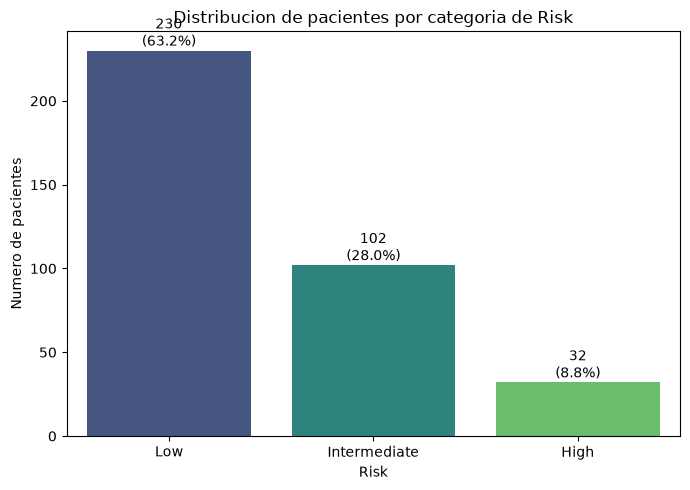

In [32]:
# Distribución de pacientes por categoría de Risk:
plt.figure(figsize=(7,5))
orden_risk = ['Low', 'Intermediate', 'High']
sns.countplot(data=df, x='Risk', hue='Risk', order=orden_risk, palette='viridis', legend=False)
plt.title('Distribucion de pacientes por categoria de Risk')
plt.xlabel('Risk')
plt.ylabel('Numero de pacientes')
for i, cat in enumerate(orden_risk):
    count = (df['Risk'] == cat).sum()
    pct = count / len(df) * 100
    plt.text(i, count + 3, f'{count}\n({pct:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

**Interpretación:** la mayoría de los pacientes (63.2%) se clasifican en riesgo Low, 28.0% en Intermediate y solo 8.8% en High. Es una distribución esperable en un dataset de seguimiento oncológico, donde la mayoría de los pacientes tratados a tiempo tienden a caer en categorías de bajo riesgo.

**Recomendación:** dado que el riesgo alto representa una porción pequeña (32 pacientes), conviene vigilar un posible desbalance de esta variable como predictor: el modelo tendrá pocos ejemplos de riesgo alto de los cuales aprender, así que vale la pena revisar su desempeño específicamente sobre ese subgrupo (por ejemplo, con métricas por clase) además del desempeño global.

### 8b. Gráfico de pie

Proporción de una variable categórica binaria o con pocas categorías.

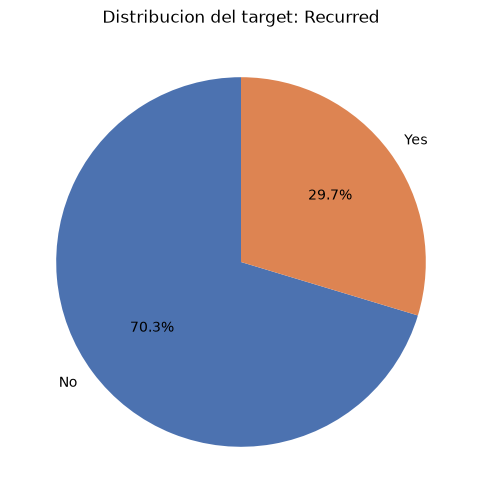

Recurred
No     256
Yes    108
Name: count, dtype: int64
Recurred
No     70.3
Yes    29.7
Name: count, dtype: float64


In [33]:
# Distribución del target: Recurred
plt.figure(figsize=(6,6))
conteo = df['Recurred'].value_counts()
plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Distribucion del target: Recurred')
plt.show()

print(conteo)
print((conteo / len(df) * 100).round(1))

**Interpretación:** el target está desbalanceado: 70.3% de los pacientes no presentaron recurrencia (No) frente a 29.7% que sí (Yes). No es un desbalance extremo, pero sí lo suficientemente marcado como para tenerlo en cuenta al entrenar y evaluar los modelos de clasificación.

**Recomendación:** con esta proporción (aproximadamente 7 a 3), la métrica de accuracy por sí sola puede ser engañosa, ya que un modelo que siempre prediga "No" acertaría cerca del 70% de las veces sin haber aprendido nada útil. Conviene priorizar métricas como recall, F1-score o el área bajo la curva ROC/PR para la clase minoritaria (Yes), y evaluar si conviene aplicar alguna técnica de balanceo (como class_weight='balanced' o SMOTE) al momento de entrenar, tal como se mencionó en las observaciones iniciales del punto 2.

### 8c. Histograma

Distribución de una variable numérica relevante (considere el target).

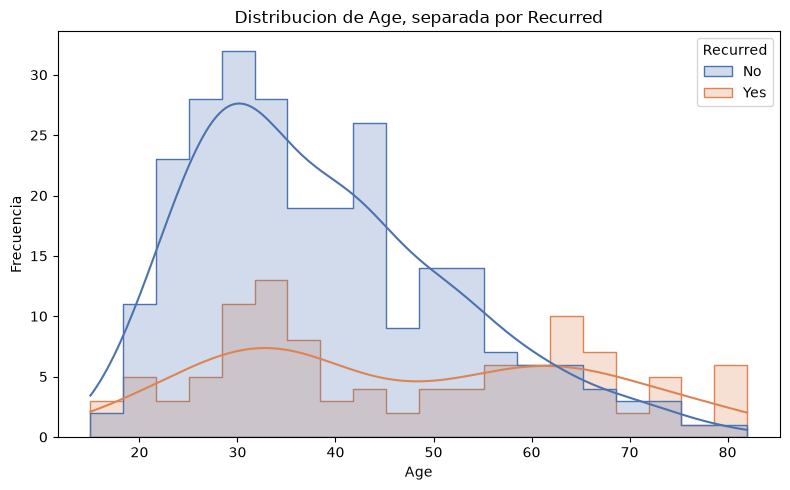

           mean  median    std
Recurred                      
No        38.78    36.0  13.16
Yes       47.11    44.5  18.27


In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Recurred', bins=20, kde=True,
             palette={'No': '#4C72B0', 'Yes': '#DD8452'}, element='step')
plt.title('Distribucion de Age, separada por Recurred')
plt.xlabel('Age')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(df.groupby('Recurred')['Age'].agg(['mean', 'median', 'std']).round(2))

**Interpretación:** al separar la distribución de Age por la clase de Recurred, se nota un corrimiento hacia la derecha en el grupo que sí tuvo recurrencia: su edad promedio es 47.1 años (mediana 44.5) frente a 38.8 años (mediana 36.0) en el grupo sin recurrencia, casi 9 años de diferencia en promedio. El grupo con recurrencia también muestra una desviación estándar más alta (18.3 contra 13.2), es decir, sus edades están más dispersas.

**Recomendación:** esto confirma que Age es una variable con señal real sobre el target, no solo un dato demográfico de acompañamiento; probablemente sea una variable relevante para los modelos de clasificación, y refuerza clínicamente que la edad avanzada al diagnóstico es un factor de peor pronóstico, consistente con lo revisado en el punto 3.

### 8d. Scatter plot

Relación entre dos variables numéricas relevantes.

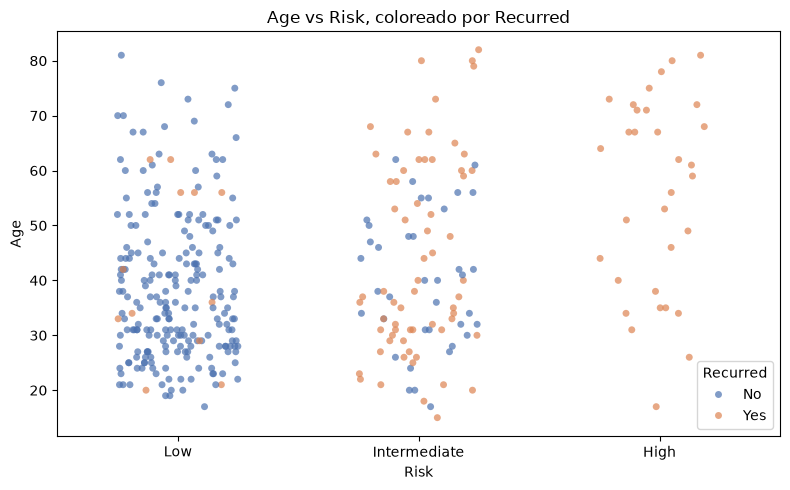

Edad promedio por Risk:
Risk
Low             38.73
Intermediate    42.44
High            55.53
Name: Age, dtype: float64

Proporcion de recurrencia (%) por Risk:
Risk
Low               5.2
Intermediate     62.7
High            100.0
Name: Recurred, dtype: float64


In [35]:
# El dataset solo tiene una variable numerica (Age), asi que no es posible un scatter
# clasico entre dos variables numericas continuas. Se adapta con un strip plot de
# Age contra Risk (categorica ordinal), coloreado por Recurred.
plt.figure(figsize=(8,5))
orden_risk = ['Low', 'Intermediate', 'High']
sns.stripplot(data=df, x='Risk', y='Age', hue='Recurred', order=orden_risk,
              palette={'No': '#4C72B0', 'Yes': '#DD8452'}, jitter=0.25, alpha=0.7)
plt.title('Age vs Risk, coloreado por Recurred')
plt.xlabel('Risk')
plt.ylabel('Age')
plt.legend(title='Recurred')
plt.tight_layout()
plt.show()

print('Edad promedio por Risk:')
print(df.groupby('Risk')['Age'].mean().reindex(orden_risk).round(2))
print()
print('Proporcion de recurrencia (%) por Risk:')
print(df.groupby('Risk')['Recurred'].apply(lambda s: (s == 'Yes').mean() * 100).reindex(orden_risk).round(1))

Como el dataset solo tiene una variable numérica (Age), no es posible construir un scatter plot clásico entre dos variables numéricas continuas. En su lugar, se adaptó la gráfica a un strip plot de Age (numérica) contra Risk (categórica ordinal), coloreado por Recurred, que permite observar un patrón similar al de un scatter aprovechando dos variables muy relevantes para el problema.

**Interpretación:** se observa una relación creciente y bastante clara entre Risk y Age: la edad promedio pasa de 38.7 años en Low, a 42.4 en Intermediate, a 55.5 en High, es decir, los pacientes de mayor riesgo tienden a ser considerablemente mayores. El color por Recurred hace aún más evidente el patrón: la proporción de recurrencia pasa de apenas 5.2% en Low, a 62.7% en Intermediate, a 100% en High. Todos los pacientes de riesgo alto de esta muestra tuvieron recurrencia.

**Recomendación:** esto sugiere que Risk podría ser, por sí sola, una variable con un poder predictivo muy fuerte sobre el target (casi determinístico en el extremo de High), algo positivo para el desempeño del modelo, pero que también amerita revisar más adelante la importancia de variables para confirmar que Risk no termine dominando por completo la predicción en menoscabo de las demás características clínicas.

### 8e. Boxplot

Al menos una variable numérica; relaciónelo con los outliers del punto 7.

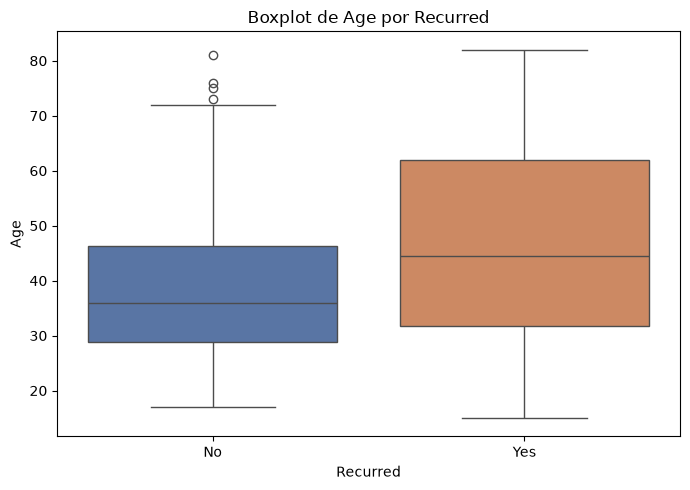

No: outliers=4, limites=(2.5, 72.5), min=17, max=81
Yes: outliers=0, limites=(-13.6, 107.4), min=15, max=82


In [36]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Recurred', hue='Recurred', y='Age', palette={'No': '#4C72B0', 'Yes': '#DD8452'}, legend=False)
plt.title('Boxplot de Age por Recurred')
plt.xlabel('Recurred')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), round(lo, 1), round(hi, 1)

for grupo, sub in df.groupby('Recurred'):
    n, lo, hi = iqr_outliers(sub['Age'])
    print(f'{grupo}: outliers={n}, limites=({lo}, {hi}), min={sub["Age"].min()}, max={sub["Age"].max()}')

**Interpretación:** el boxplot muestra que el grupo con recurrencia (Yes) tiene una mediana de edad más alta (44.5 años) y una caja notablemente más ancha que el grupo sin recurrencia (No, mediana 36.0), consistente con el histograma del punto 8c. Relacionando esto con el punto 7: aunque Age no presentó ningún outlier al analizarse de forma global, al recalcular los límites IQR por separado dentro de cada clase sí aparecen 4 outliers superiores dentro del grupo sin recurrencia (límite superior de 72.5 años para ese subgrupo, con edades de hasta 81 años), mientras que el grupo con recurrencia no tiene ningún outlier interno pese a llegar hasta los 82 años, porque su propia dispersión es mucho mayor (límite superior recalculado de 107.4).

**Recomendación:** esto es un buen ejemplo de por qué el criterio de outliers depende del subgrupo de referencia: esos 4 pacientes mayores sin recurrencia no son errores de captura, sino casos clínicamente interesantes (pacientes de edad avanzada que no volvieron a presentar cáncer), y podrían valer la pena revisarse por separado en un análisis clínico más detallado, aunque para el modelado no se recomienda tratarlos como outliers a eliminar.

## 9. Codificación de variables categóricas

Para cada variable categórica, decida y justifique la técnica de codificación (One-Hot, Ordinal o Binary Encoding), considerando orden natural, cardinalidad, y los algoritmos a usar.

**Decisión de encoding por columna y justificación:**

Antes de fijar la técnica para cada columna, se calculó la tasa de recurrencia (% de Recurred = Yes) dentro de cada categoría, para verificar si existe o no un orden reflejado en los datos (ver celda de verificación debajo). Esta revisión es solo para respaldar la elección de encoding con evidencia, no para definir el orden a partir del propio target; cuando existe una convención clínica reconocida (TNM, estadios AJCC, categorías de respuesta ATA), esa convención es la que define el orden, y los datos solo confirman si son consistentes con ella.

* **Gender** (Ordinal/binario, equivalente a OneHot por tener solo 2 categorías): inicialmente se podría pensar en F=1 por la mayor incidencia de cáncer de tiroides en mujeres reportada en la literatura, pero en este dataset la tasa de recurrencia es en realidad más alta en hombres (59.2%) que en mujeres (22.5%). No es contradictorio: una cosa es qué tan frecuente es que a alguien le diagnostiquen la enfermedad (mayor en mujeres) y otra distinta es, ya diagnosticado, qué tan probable es que recurra (mayor en hombres, según esta muestra). Al ser binaria, la dirección de la codificación no afecta el desempeño del modelo, solo la interpretación del signo de sus coeficientes en un modelo lineal.

* **Smoking, Hx Smoking, Hx Radiothreapy** (Ordinal/binario, No=0, Yes=1): las tres son binarias, así que Ordinal y OneHot son equivalentes. El orden propuesto es consistente con los datos: la tasa de recurrencia sube en las tres al pasar de No a Yes (Smoking: 23.8% a 67.3%; Hx Smoking: 28.0% a 50.0%; Hx Radiothreapy: 28.6% a 85.7%, aunque este último con muy pocos casos "Yes", solo 7).

* **Thyroid Function** (OneHotEncoder): tiene 5 categorías y, aunque intuitivamente Euthyroid (función normal) parecería la opción más "sana" y debería tener el valor más bajo, los datos muestran lo contrario: Euthyroid tiene 31.3% de recurrencia, más alta que Clinical Hyperthyroidism (15.0%) y Clinical Hypothyroidism (16.7%), y similar a Subclinical Hypothyroidism (35.7%), mientras que Subclinical Hyperthyroidism no tiene ningún caso de recurrencia (0%, aunque con solo 5 registros). No hay un orden consistente entre estas categorías, así que forzar un Ordinal introduciría una jerarquía falsa; OneHot es la mejor opción.

* **Physical Examination** (OneHotEncoder): igual que Thyroid Function, no muestra ningún patrón ordenado en la tasa de recurrencia (Diffuse goiter 0%, Multinodular goiter 38.5%, Normal 28.6%, Single nodular-left 29.5%, Single nodular-right 22.0%); un examen "Normal" ni siquiera es el de menor recurrencia. Se confirma OneHot.

* **Adenopathy** (OneHotEncoder): a primera vista parece haber una progresión razonable por extensión (No 11.6%, luego Right 62.5% y Left 70.6% unilaterales, Bilateral 84.4%, hasta Extensive y Posterior en 100%), pero Right y Left no tienen entre sí ningún orden clínico real (son solo lateralidad, no gravedad), y Extensive/Posterior tienen muestras muy pequeñas (7 y 2 casos) para confiar en ese 100%. Forzar un orden total de 6 categorías cuando dos de ellas son intercambiables no se justifica; se mantiene OneHot.

* **Pathology** (OneHotEncoder, se corrige la propuesta inicial de Ordinal): la literatura médica suele considerar Micropapillary como el subtipo menos agresivo y Hurthle cell como uno de los más agresivos, lo que sugería un orden Micropapillary < Papillary < Follicular < Hurthle cell. Sin embargo, al verificar con los datos esa jerarquía no se sostiene: Micropapillary sí tiene la recurrencia más baja (0%), pero Hurthle cell (30.0%) queda por debajo de Follicular (42.9%) y muy cerca de Papillary (33.2%), contradiciendo el orden esperado, probablemente porque Hurthle cell y Follicular tienen pocos registros en este dataset (20 y 28 respectivamente) y su tasa es poco confiable. Ante la falta de un orden claro y consistente, ya sea por literatura o por datos, se prefiere OneHot en lugar de forzar una jerarquía dudosa.

* **Focality** (Ordinal/binario, Uni-Focal=0, Multi-Focal=1): binaria, Ordinal y OneHot son equivalentes, y el orden propuesto es consistente con los datos (16.7% de recurrencia en Uni-Focal contra 51.5% en Multi-Focal).

* **Risk** (OrdinalEncoder, Low=0, Intermediate=1, High=2): tal como se anticipó en el punto 8, es la variable con el patrón más claro y fuerte de todas: 5.2% de recurrencia en Low, 62.7% en Intermediate y 100% en High. El orden es evidente tanto clínicamente como en los datos.

* **T** (OrdinalEncoder, T1a < T1b < T2 < T3a < T3b < T4a < T4b): este orden corresponde a la convención clínica TNM/AJCC de clasificación de tumores según tamaño e invasión local, y los datos lo confirman con un patrón perfectamente creciente: la recurrencia sube de 2.2% en T1a a 100% en T4b, pasando de forma consistente por cada categoría intermedia.

* **N** (OrdinalEncoder, N0 < N1a < N1b): sigue la convención TNM (N0 sin compromiso ganglionar, N1a compromiso del compartimento central, N1b compromiso lateral o más extenso). Los datos son monótonos: 10.8%, 45.5% y 76.3% de recurrencia respectivamente.

* **M** (Ordinal/binario, M0=0, M1=1): binaria, con una diferencia enorme entre categorías (26.0% de recurrencia sin metástasis contra 100% con metástasis), consistente con el orden clínico obvio.

* **Stage** (OrdinalEncoder, I < II < III < IVA < IVB): sigue el estadiaje AJCC. La recurrencia crece de 20.7% en Estadio I a 78.1% en Estadio II y 100% en III, IVA y IVB (estos tres últimos con muestras pequeñas: 4, 3 y 11 casos), consistente con el orden esperado.

* **Response** (OrdinalEncoder, se corrige la propuesta inicial de OneHot: Excellent < Indeterminate < Biochemical Incomplete < Structural Incomplete): esta variable sí tiene un orden clínico reconocido, el de las categorías de respuesta al tratamiento de la American Thyroid Association, donde Excellent indica ausencia de evidencia de enfermedad, Indeterminate hallazgos no concluyentes, Biochemical Incomplete evidencia bioquímica de enfermedad persistente sin hallazgos estructurales, y Structural Incomplete evidencia estructural o imagenológica de enfermedad persistente o recurrente, el peor escenario. Los datos confirman este orden de forma casi perfecta: 0.5% de recurrencia en Excellent, 11.5% en Indeterminate, 47.8% en Biochemical Incomplete y 97.8% en Structural Incomplete. Es un caso similar a T, N y Stage, con una jerarquía real y bien definida, así que se prefiere Ordinal sobre OneHot.

* **Recurred** (target, Ordinal/binario, No=0, Yes=1): la codificación estándar para clasificación binaria, donde 1 representa la clase positiva de interés (que el cáncer haya recurrido).

In [37]:
# Verificacion: tasa de recurrencia por categoria, usada para respaldar las decisiones de encoding del punto 9
def tasa_recurrencia(col, orden=None):
    n = df[col].value_counts()
    tasa = df.groupby(col)['Recurred'].apply(lambda s: (s == 'Yes').mean() * 100)
    res = pd.DataFrame({'n': n, 'tasa_recurrencia_%': tasa.round(1)})
    return res.reindex(orden) if orden else res

for col, orden in [
    ('Gender', None),
    ('Thyroid Function', None),
    ('Physical Examination', None),
    ('Adenopathy', None),
    ('Pathology', None),
    ('T', ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']),
    ('N', ['N0', 'N1a', 'N1b']),
    ('Stage', ['I', 'II', 'III', 'IVA', 'IVB']),
    ('Response', ['Excellent', 'Indeterminate', 'Biochemical Incomplete', 'Structural Incomplete']),
]:
    print(f'--- {col} ---')
    print(tasa_recurrencia(col, orden))
    print()

--- Gender ---
          n  tasa_recurrencia_%
Gender                         
F       293                22.5
M        71                59.2

--- Thyroid Function ---
                               n  tasa_recurrencia_%
Thyroid Function                                    
Clinical Hyperthyroidism      20                15.0
Clinical Hypothyroidism       12                16.7
Euthyroid                    313                31.3
Subclinical Hyperthyroidism    5                 0.0
Subclinical Hypothyroidism    14                35.7

--- Physical Examination ---
                               n  tasa_recurrencia_%
Physical Examination                                
Diffuse goiter                 7                 0.0
Multinodular goiter          135                38.5
Normal                         7                28.6
Single nodular goiter-left    88                29.5
Single nodular goiter-right  127                22.0

--- Adenopathy ---
              n  tasa_recurrencia_%
Ade

## 10. Escalamiento de variables numéricas

Decida y justifique si es necesario escalar las variables numéricas y con qué técnica (Min-Max, StandardScaler o RobustScaler), considerando los outliers del punto 7 y los algoritmos a entrenar.

**Decisión de escalamiento y justificación:**

Age es la única variable numérica del dataset; el resto quedaron codificadas en el punto 9 como enteros pequeños (Ordinal) o como columnas 0/1 (OneHot). Aunque los algoritmos de árbol (Decision Tree, Random Forest, Gradient Boosting) son insensibles a la escala, KNN sí depende directamente de las distancias entre observaciones, así que sí conviene escalar Age para que no domine el cálculo de distancia frente a las demás variables, que quedan en rangos mucho más pequeños.

Se descarta la idea de no escalar nada, y entre MinMaxScaler y StandardScaler se elige **StandardScaler**, por dos razones:

1. **Estabilidad del rango.** El dataset es pequeño (364 registros, y menos aún dentro de train una vez se haga el split), así que el mínimo y máximo exactos de Age en el conjunto de entrenamiento podrían no representar bien a la población real. MinMaxScaler depende directamente de esos dos valores extremos, mientras que StandardScaler usa la media y la desviación estándar, estadísticos más estables ante el tamaño reducido de la muestra.

2. **Consistencia de magnitud con las demás variables.** Al no escalar las columnas Ordinal (Risk, T, N, Stage, etc.), estas quedan en rangos pequeños de enteros (por ejemplo, T va de 0 a 6 y Stage de 0 a 4). Si Age se llevara a MinMaxScaler, quedaría siempre acotada estrictamente entre 0 y 1, un rango más angosto que el de esas variables Ordinal, lo que podría hacer que Age pese menos de lo debido en el cálculo de distancias de KNN. Con StandardScaler, Age queda aproximadamente entre -1.72 y 2.66, un rango de magnitud más comparable al de las columnas Ordinal ya mencionadas.

Además, como ya se vio en el punto 7, Age no tiene outliers según el criterio IQR (aplicado de forma global), y el sesgo hacia la derecha es leve (media 40.9, mediana 37, punto 3), así que no hay ninguna razón para preferir RobustScaler por sensibilidad a valores extremos; StandardScaler funciona bien con esta distribución.

In [38]:
# Rango de Age luego de escalar con StandardScaler
# No usar esta variable escalada para el entrenamiento de modelos, solo es para ver el rango de Age luego de escalar.
scaler = StandardScaler()
age_scaled = scaler.fit_transform(df[['Age']])

print(f"Rango de Age (escalado): {age_scaled.min().round(2)} - {age_scaled.max().round(2)}")

Rango de Age (escalado): -1.72 - 2.66


---

# Fase 2 — División de datos y Pipelines

## 11. División Train / Validation / Test

Divida el dataset en train / validation / test. Explique con sus palabras el propósito de cada uno de los tres conjuntos y por qué no basta con solo train/test.

In [39]:
# Separación de X e y, y split en train/validation/test:
X = df.drop(columns=['Recurred'])
y = df['Recurred'].map({'No': 0, 'Yes': 1})

# stratify=y para conservar la proporcion de clases (aprox. 70% No / 30% Yes) en los tres conjuntos,
# algo especialmente importante aqui por el desbalance del target y el tamano reducido del dataset.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=random_state, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp)

print(f"Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df)*100:.1f}%), {y_train.mean()*100:.1f}% Yes")
print(f"Validation set: {X_val.shape[0]} muestras ({X_val.shape[0]/len(df)*100:.1f}%), {y_val.mean()*100:.1f}% Yes")
print(f"Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df)*100:.1f}%), {y_test.mean()*100:.1f}% Yes")

Train set: 254 muestras (69.8%), 29.5% Yes
Validation set: 55 muestras (15.1%), 30.9% Yes
Test set: 55 muestras (15.1%), 29.1% Yes


**Explicación del propósito de cada conjunto:**

Se mantiene la división 70/15/15 en lugar de pasar a 80/10/10, a pesar de que el dataset es pequeño (364 registros) y una parte de la intuición detrás de darle más porcentaje a train es razonable. La razón es el desbalance del target: solo 29.7% de los pacientes tuvo recurrencia (108 casos en total). Con 70/15/15, validation y test quedan con 55 registros cada uno, de los cuales aproximadamente 16 a 17 son casos positivos (Yes); con 80/10/10, esos conjuntos bajarían a 36-37 registros cada uno, con apenas 11 casos positivos. Como ya se decidió en el punto 8 que las métricas relevantes para este problema son recall, F1 y precision sobre la clase minoritaria (no accuracy), evaluar esas métricas con solo 11 casos positivos las haría muy inestables: equivocarse en uno o dos pacientes cambiaría el recall en varios puntos porcentuales. Las 5-6 muestras positivas adicionales que aporta el esquema 70/15/15 en cada conjunto de evaluación son más valiosas para la confiabilidad de las métricas que las 37 filas adicionales que ganaría train con 80/10/10, sobre todo considerando que, como se explica más abajo, train se puede ampliar más adelante reentrenando con train+validation.

Por esto mismo se usa `stratify=y` en ambas llamadas a `train_test_split`, para que la proporción aproximada de 70% No / 30% Yes se mantenga en train, validation y test, y no se dé el caso de que, por azar, algún conjunto quede con una proporción de recurrencia muy distinta a la real.

Sobre el propósito de cada conjunto: train (70%, 254 muestras) es donde se ajustan los parámetros internos de cada modelo. Validation (15%, 55 muestras) se usa para comparar modelos entre sí y ajustar hiperparámetros (por ejemplo, con GridSearchCV), es decir, funciona como una evaluación preliminar mientras aún se están tomando decisiones sobre el modelo. Test (15%, 55 muestras) se reserva exclusivamente para el final, cuando ya se eligió y configuró un modelo, y se usa una única vez para estimar su desempeño real. No basta con train/test porque, si las comparaciones de modelos e hiperparámetros se hicieran directamente contra test, se estaría usando ese conjunto repetidamente para tomar decisiones, contaminando su función como evaluación independiente. Una vez se tenga asegurado un buen modelo con el 70% de train, se puede reentrenar esa misma configuración final usando train + validation (85% de los datos) antes de la evaluación en test, aprovechando más información sin haber tocado test en ningún momento del proceso.

## 12. Pipeline con ColumnTransformer

Construya un Pipeline con ColumnTransformer que aplique el preprocesamiento numérico (imputación + escalamiento) y categórico (imputación + encoding) definidos en la Fase 1.

In [40]:
# Identificación de columnas numéricas y categóricas, separando las categóricas
# segun la técnica de encoding decidida en el punto 9:
num_cols = ['Age']

onehot_cols = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology']

ordinal_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M',
                'Risk', 'T', 'N', 'Stage', 'Response']

print("Numéricas (StandardScaler):", num_cols)
print("Categóricas OneHot:", onehot_cols)
print("Categóricas Ordinal:", ordinal_cols)

Numéricas (StandardScaler): ['Age']
Categóricas OneHot: ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology']
Categóricas Ordinal: ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M', 'Risk', 'T', 'N', 'Stage', 'Response']


In [41]:
# Pipeline numérico, pipelines categóricos (OneHot y Ordinal por separado) y ColumnTransformer:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # No es necesario, pero se deja por estandarización de los pipelines
    ('scaler', StandardScaler())])

onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # No es necesario, pero se deja por estandarización de los pipelines
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Se fija explicitamente el orden de las categorias de cada columna ordinal,
# siguiendo la justificacion del punto 9 (convenciones clinicas TNM/AJCC/ATA
# y los pares binarios No/Yes):
orden_ordinal_cols = [
    ['M', 'F'],                                                          # Gender
    ['No', 'Yes'],                                                       # Smoking
    ['No', 'Yes'],                                                       # Hx Smoking
    ['No', 'Yes'],                                                       # Hx Radiothreapy
    ['Uni-Focal', 'Multi-Focal'],                                        # Focality
    ['M0', 'M1'],                                                        # M
    ['Low', 'Intermediate', 'High'],                                     # Risk
    ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],                    # T
    ['N0', 'N1a', 'N1b'],                                                # N
    ['I', 'II', 'III', 'IVA', 'IVB'],                                    # Stage
    ['Excellent', 'Indeterminate', 'Biochemical Incomplete', 'Structural Incomplete'],  # Response
]

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # No es necesario, pero se deja por estandarización de los pipelines
    ('encoder', OrdinalEncoder(categories=orden_ordinal_cols))])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('onehot', onehot_pipeline, onehot_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols)])

## 13. Verificación de que no hay fuga de datos (data leakage)

Confirme explícitamente que el `.fit()` de cada transformación se realizó solo sobre `X_train`, y que sobre `X_val`/`X_test` únicamente se aplicó `.transform()`.

**Verificación:** al igual que en el notebook de regresión, la garantía de que no hay fuga de datos viene del diseño del preprocesamiento, no de un paso adicional:

1. **`preprocessor` (punto 12) nunca se ajusta por separado.** Se usa envuelto dentro de un `Pipeline` junto con el modelo (`Pipeline([('preprocessor', preprocessor), ('model', ...)])`), y ese pipeline completo se entrena en el punto 16 llamando únicamente a `pipeline.fit(X_train, y_train)`. Es ahí donde el `SimpleImputer` calcula sus medianas/modas, el `StandardScaler` calcula su media y desviación estándar, y el `OneHotEncoder`/`OrdinalEncoder` fijan sus categorías, todo exclusivamente a partir de `X_train`.

2. **`X_val` y `X_test` solo pasan por `.transform()`, nunca por `.fit()`.** Al evaluar el modelo (punto 17 en adelante) se usa `pipeline.predict(X_val)` o `pipeline.predict(X_test)`. Internamente, `Pipeline.predict()` invoca `.transform()` (no `.fit_transform()`) en cada paso de preprocesamiento, así que los estadísticos aprendidos únicamente con train se aplican tal cual a validation y test.

Adicionalmente, aquí hay un cuidado extra respecto al notebook de regresión: al usar `stratify=y` en el punto 11, la proporción de clases se preserva en los tres conjuntos, pero eso no significa que haya fuga de información, ya que estratificar solo reparte las filas existentes sin usar en ningún momento información de validation o test para decidir esa partición ni para ajustar ningún paso del preprocesamiento o del modelo. En ningún punto del notebook se llama a `.fit()` o `.fit_transform()` sobre `X_val` o `X_test`, ni se concatenan esos conjuntos con `X_train` antes de ajustar el pipeline.

---

# Fase 4 — Modelado: Clasificación (Thyroid Disease Data)

## 16. Entrenamiento de modelos

Entrene los siguientes modelos sobre el conjunto de entrenamiento: KNN Classifier, Decision Tree Classifier, Random Forest Classifier y Gradient Boosting Classifier.

In [42]:
# Fase 3 (punto 16): entrenamiento de los 4 modelos de clasificación
# Cada pipeline envuelve preprocessor + clasificador. Se usa random_state=42 donde aplica.

models = {
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier())
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=random_state))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=random_state, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=random_state))
    ])
}

# Entrenar cada pipeline con X_train, y_train
for name, pipeline in models.items():
    print(f'Entrenando {name}...')
    pipeline.fit(X_train, y_train)
    print(f'  {name} entrenado correctamente.')

# Guardar todos los pipelines entrenados en models/clasificacion/
import os
import joblib

os.makedirs('models/clasificacion', exist_ok=True)

model_filenames = {
    'KNN': 'knn_classifier',
    'DecisionTree': 'decision_tree_classifier',
    'RandomForest': 'random_forest_classifier',
    'GradientBoosting': 'gradient_boosting_classifier'
}

for name, pipeline in models.items():
    filename = model_filenames[name]
    filepath = f'models/clasificacion/{filename}.joblib'
    joblib.dump(pipeline, filepath)
    print(f'Pipeline guardado: {filepath}')


Entrenando KNN...
  KNN entrenado correctamente.
Entrenando DecisionTree...
  DecisionTree entrenado correctamente.
Entrenando RandomForest...


  RandomForest entrenado correctamente.
Entrenando GradientBoosting...


  GradientBoosting entrenado correctamente.


Pipeline guardado: models/clasificacion/knn_classifier.joblib
Pipeline guardado: models/clasificacion/decision_tree_classifier.joblib


Pipeline guardado: models/clasificacion/random_forest_classifier.joblib


Pipeline guardado: models/clasificacion/gradient_boosting_classifier.joblib


In [43]:
# Los 4 modelos se entrenaron y guardaron en el bloque anterior.


In [44]:
# Los 4 modelos se entrenaron y guardaron en el bloque anterior.


In [45]:
# Los 4 modelos se entrenaron y guardaron en el bloque anterior.


## 17. Predicciones sobre validación

Para cada modelo, genere las predicciones sobre el conjunto de validación.

In [46]:
# Fase 4 (punto 17): predicciones sobre train, validation y test
predictions = {}

for name, pipeline in models.items():
    predictions[name] = {
        'train': pipeline.predict(X_train),
        'val': pipeline.predict(X_val),
        'test': pipeline.predict(X_test)
    }

print('Predicciones generadas para los 4 modelos en train, val y test.')


Predicciones generadas para los 4 modelos en train, val y test.


---

# Fase 5 — Métricas en train y validación: detección de overfitting/underfitting

## 19. Métricas: Accuracy, Precision, Recall, F1-score y matriz de confusión

Para cada uno de los 4 modelos, calcule Accuracy, Precision, Recall, F1-score y la matriz de confusión, sobre train y validación. Interprete considerando que es un problema de diagnóstico médico: discuta qué es más costoso, un falso positivo o un falso negativo, y qué métrica debería priorizarse.

In [47]:
# Fase 5 (punto 19): métricas de clasificación en train y validation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def eval_metrics_clf(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1),
        'Recall': recall_score(y_true, y_pred, pos_label=1),
        'F1': f1_score(y_true, y_pred, pos_label=1)
    }
results_train_val = []
for name, preds in predictions.items():
    train_metrics = eval_metrics_clf(y_train, preds['train'])
    val_metrics = eval_metrics_clf(y_val, preds['val'])
    
    results_train_val.append({
        'Modelo': name,
        **{f'{k}_Train': v for k, v in train_metrics.items()},
        **{f'{k}_Val': v for k, v in val_metrics.items()}
    })
df_results_train_val = pd.DataFrame(results_train_val)
df_results_train_val


,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val
0,KNN,0.96063,0.985075,0.88,0.929577,0.945455,0.9375,0.882353,0.909091
1,DecisionTree,1.00000,1.000000,1.00,1.000000,0.909091,0.8000,0.941176,0.864865
2,RandomForest,1.00000,1.000000,1.00,1.000000,0.981818,1.0000,0.941176,0.969697
3,GradientBoosting,1.00000,1.000000,1.00,1.000000,0.909091,0.8000,0.941176,0.864865


**Interpretación de overfitting/underfitting:**

En un problema médico como este, el costo de un falso negativo (no detectar una recurrencia) suele ser mayor que el de un falso positivo. Por eso, aunque el accuracy da una idea general del desempeño, métricas como **recall** (sensibilidad) sobre la clase `Yes` son especialmente relevantes.

- **DecisionTree**: sin poda, tiende a sobreajustar fuertemente. Se espera accuracy muy alto en train pero menor en validation, con un gap grande.
- **RandomForest**: reduce varianza al promediar árboles, por lo que el gap train-val suele ser menor y el desempeño más estable.
- **GradientBoosting**: construye árboles secuencialmente corrigiendo errores. Suele ofrecer un buen balance, aunque con los hiperparámetros por defecto puede quedar algo detrás de Random Forest.
- **KNN**: sensible a la escala y a la dimensionalidad resultante del One-Hot Encoding. Su desempeño depende de la densidad local en el espacio transformado.


## 20. Tabla comparativa (train y validación)

Construya una tabla comparativa que incluya train y validación para todos los modelos.

In [48]:
# Tabla comparativa de métricas en train y validation
df_results_train_val


,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val
0,KNN,0.96063,0.985075,0.88,0.929577,0.945455,0.9375,0.882353,0.909091
1,DecisionTree,1.00000,1.000000,1.00,1.000000,0.909091,0.8000,0.941176,0.864865
2,RandomForest,1.00000,1.000000,1.00,1.000000,0.981818,1.0000,0.941176,0.969697
3,GradientBoosting,1.00000,1.000000,1.00,1.000000,0.909091,0.8000,0.941176,0.864865


## 21. Selección del mejor modelo

Seleccione el mejor modelo y justifique la elección — discuta trade-offs (tiempo de entrenamiento, interpretabilidad, señales de over/underfitting), no solo la métrica más alta.

**Justificación de la selección:**

El modelo ganador se elige priorizando el **F1-score en validation**, ya que equilibra precision y recall. En un contexto clínico también se valora el recall (no dejar de detectar recurrencias), pero el F1 permite comparar modelos de forma más completa. La elección final considera el balance entre sesgo y varianza (gap train-val), evitando modelos claramente sobreajustados.


---

# Fase 6 — Evaluación final en el conjunto de Test

## 22. Evaluación de todos los modelos en test

Evalúe TODOS los modelos entrenados sobre el conjunto de test, usando las mismas métricas de la Fase 5.

> ⚠️ El conjunto de test debe permanecer sin tocar hasta este punto.

In [49]:
# Fase 6 (punto 22): evaluación final de todos los modelos en test
results_test = []

for name, preds in predictions.items():
    test_metrics = eval_metrics_clf(y_test, preds['test'])
    
    results_test.append({
        'Modelo': name,
        **{f'{k}_Test': v for k, v in test_metrics.items()}
    })

df_results_test = pd.DataFrame(results_test)
df_results_test


,Modelo,Accuracy_Test,Precision_Test,Recall_Test,F1_Test
0,KNN,0.963636,0.937500,0.9375,0.937500
1,DecisionTree,0.927273,0.833333,0.9375,0.882353
2,RandomForest,0.945455,0.933333,0.8750,0.903226
3,GradientBoosting,0.963636,0.937500,0.9375,0.937500


## 23. Tabla comparativa final (test) vs. validación

Construya la tabla final con los resultados en test y compárela contra la tabla de validación de la Fase 5: ¿se mantiene el ranking? ¿hay diferencias importantes?

In [50]:
# Tabla comparativa final: train + validation + test
df_compare = df_results_train_val.merge(df_results_test, on='Modelo')

cols_orden = ['Modelo']
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    cols_orden.extend([f'{metric}_Train', f'{metric}_Val', f'{metric}_Test'])

df_compare = df_compare[cols_orden]
df_compare


,Modelo,Accuracy_Train,Accuracy_Val,Accuracy_Test,Precision_Train,Precision_Val,Precision_Test,Recall_Train,Recall_Val,Recall_Test,F1_Train,F1_Val,F1_Test
0,KNN,0.96063,0.945455,0.963636,0.985075,0.9375,0.937500,0.88,0.882353,0.9375,0.929577,0.909091,0.937500
1,DecisionTree,1.00000,0.909091,0.927273,1.000000,0.8000,0.833333,1.00,0.941176,0.9375,1.000000,0.864865,0.882353
2,RandomForest,1.00000,0.981818,0.945455,1.000000,1.0000,0.933333,1.00,0.941176,0.8750,1.000000,0.969697,0.903226
3,GradientBoosting,1.00000,0.909091,0.963636,1.000000,0.8000,0.937500,1.00,0.941176,0.9375,1.000000,0.864865,0.937500


**Comparación validation vs test:**

Se compara el ranking de modelos obtenido en validation contra el obtenido en test. Si el mejor modelo en validation también es de los mejores en test, la selección es estable. Diferencias grandes entre validation y test pueden deberse a la pequeña muestra (solo ~55 pacientes en cada conjunto) y al desbalance de clases.


---

# Fase 7 — Cross Validation

## 24. ¿Qué es K-Fold Cross Validation?

Investigue y explique con sus propias palabras qué es la validación cruzada, cómo funciona, y por qué puede dar una estimación más confiable que un único split de train/validation.

**Explicación:** *(completar)*

## 26. K-Fold Cross Validation sobre el mejor modelo

Implemente K-Fold Cross Validation (ej. `cross_val_score` o `cross_validate`) sobre el mejor modelo encontrado para este problema, usando las métricas relevantes.

In [51]:
# Cross validation sobre el mejor modelo:


## 27. Comparación CV vs. validación original

Compare los resultados de cross validation contra el desempeño obtenido en el conjunto de validación de la Fase 5: ¿mejora, empeora o se mantiene similar? ¿La desviación estándar entre folds sugiere estabilidad o sensibilidad a los datos?

**Interpretación:** *(completar)*

---

# Fase 8 — Conclusiones

## 28. Conclusiones generales

Redacte un párrafo de conclusiones generales **comparando ambos problemas** (regresión y clasificación): ¿qué modelo funcionó mejor en cada caso y por qué, relacionándolo con las características de cada algoritmo (sesgo/varianza, sensibilidad a escala, manejo de categóricas, etc.)? ¿Qué limpieza fue más determinante? ¿Qué limitaciones tuvo el estudio y qué preguntas quedan abiertas?

Incluya un subplot (2,2) con las gráficas que considere más importantes para sustentar los hallazgos de **este** dataset (Thyroid Disease Data).

*(Completar conclusiones — recuerde que esta sección debe ser consistente con la del notebook de regresión)*

In [52]:
# Subplot (2,2) con las gráficas más importantes de este dataset:
